# Milestone 1 — Data Report & EDA
## Real-Time Retail Feedback Intelligence — *ChicStyle*

**Problem Statement:** 
Retailers need a smart feedback analysis system that can automatically process large volumes 
of real-time customer reviews, accurately detect sentiment (positive, negative, neutral), identify 
which product or service the feedback is about, and highlight urgent or high-impact issues. 
Traditional NLP models often struggle with this because they depend on fixed rules and limited 
training data. They can’t easily understand complex or mixed feedback. For example, in the 
review “The fit is great but the color was not as per the product image,” older systems may give 
only one sentiment, either positive or negative, missing that the review talks positively about the 
fit but negatively about the color. 
  
Generative  AI  models  are  much  better  at this. They can understand the full meaning of a 
sentence, separate opinions about different products, and catch mixed emotions. This helps 
retailers get more accurate insights and respond to customer problems faster. 

**Dataset — *Women's E-Commerce Clothing Reviews*.** Each row is one customer review.

| Column | Meaning |
|---|---|
| `Clothing.ID` | Unique product identifier |
| `Age` | Reviewer age |
| `Title` | Review title |
| `Review.Text` | Full review body |
| `Rating` | Star rating 1 (worst) – 5 (best) — **target variable** |
| `Recommended.IND` | 1 = recommends, 0 = does not |
| `Positive.Feedback.Count` | # other customers who found the review helpful |
| `Division.Name` | High-level product division |
| `Department.Name` | Product department |
| `Class.Name` | Specific product class |


# Section 1 — Data Description & Understanding

### 1.1 Setup — Imports & Configuration

In [1]:
# Core data-analysis and visualization libraries
import pandas as pd                 # dataframes / IO
import numpy as np                  # numeric operations
import matplotlib.pyplot as plt     # base plotting
import seaborn as sns               # statistical visualizations

### 1.2 Detailed description of the data (rows, columns, etc.)

In [2]:
# Load the dataset. NOTE: the file is SEMICOLON-separated and its first unnamed
# column is just a row index, so we pass sep=';' and index_col=0.
df = pd.read_csv('Dataset Real-Time Retail Feedback Intelligence.csv', sep=';', index_col=0)

In [3]:
#Printing top 5 rows
df.head()

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
#Printing last 5 rows
df.tail()

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
23482,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23483,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23484,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23485,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses
23486,1104,52,Please make more like this one!,This dress in a lovely platinum is feminine an...,5,1,22,General Petite,Dresses,Dresses


In [5]:
# High-level size description of the dataset
print(f'Number of rows (records) : {df.shape[0]:,}')
print(f'Number of columns        : {df.shape[1]}')
print(f'Column names             : {list(df.columns)}')

Number of rows (records) : 23,486
Number of columns        : 10
Column names             : ['Clothing.ID', 'Age', 'Title', 'Review.Text', 'Rating', 'Recommended.IND', 'Positive.Feedback.Count', 'Division.Name', 'Department.Name', 'Class.Name']


### 1.3 Descriptive statistics of the data

In [6]:
# df.info() -> dtype and non-null count for every column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 1 to 23486
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing.ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review.Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended.IND          23486 non-null  int64
 6   Positive.Feedback.Count  23486 non-null  int64
 7   Division.Name            23472 non-null  str  
 8   Department.Name          23472 non-null  str  
 9   Class.Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB


In [7]:
# Statistical summary of NUMERIC columns (count, mean, std, min, quartiles, max)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Clothing.ID,23486.0,918.118709,203.298980,0.0,861.0,936.0,1078.0,1205.0
Age,23486.0,43.198544,12.279544,18.0,34.0,41.0,52.0,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.0,5.0,5.0,5.0
Recommended.IND,23486.0,0.822362,0.382216,0.0,1.0,1.0,1.0,1.0
Positive.Feedback.Count,23486.0,2.535936,5.702202,0.0,0.0,1.0,3.0,122.0


In [8]:
# Statistical summary of NON-NUMERIC/text columns (count, unique, top value, frequency)
df.describe(include=['object', 'string']).T

,count,unique,top,freq
Title,19676,13993,Love it!,136
Review.Text,22641,22634,Perfect fit and i've gotten so many compliment...,3
Division.Name,23472,3,General,13850
Department.Name,23472,6,Tops,10468
Class.Name,23472,20,Dresses,6319


### 1.4 Variable types & attributes; rename if required

In [9]:
# Classify each variable by its true statistical type (not just pandas dtype).
# This informs which plots/tests are appropriate later.
var_types = pd.DataFrame({
    'column': df.columns,
    'pandas_dtype': [str(t) for t in df.dtypes],
    'variable_type': [
        'Nominal / Identifier',   # Clothing.ID  - label, not a quantity
        'Continuous (discrete)',  # Age
        'Text (nominal)',         # Title
        'Text (nominal)',         # Review.Text
        'Ordinal',                # Rating 1..5 has natural order
        'Binary / Nominal',       # Recommended.IND
        'Continuous (discrete)',  # Positive.Feedback.Count
        'Nominal (categorical)',  # Division.Name
        'Nominal (categorical)',  # Department.Name
        'Nominal (categorical)',  # Class.Name
    ],
    'unique_values': df.nunique().values,
})
var_types

,column,pandas_dtype,variable_type,unique_values
0,Clothing.ID,int64,Nominal / Identifier,1206
1,Age,int64,Continuous (discrete),77
2,Title,str,Text (nominal),13993
3,Review.Text,str,Text (nominal),22634
4,Rating,int64,Ordinal,5
5,Recommended.IND,int64,Binary / Nominal,2
6,Positive.Feedback.Count,int64,Continuous (discrete),82
7,Division.Name,str,Nominal (categorical),3
8,Department.Name,str,Nominal (categorical),6
9,Class.Name,str,Nominal (categorical),20


In [10]:
# Rename dotted CamelCase columns to clean, consistent snake_case for easier reference.
rename_map = {
    'Clothing.ID': 'clothing_id',
    'Age': 'age',
    'Title': 'title',
    'Review.Text': 'review_text',
    'Rating': 'rating',
    'Recommended.IND': 'recommended_ind',
    'Positive.Feedback.Count': 'positive_feedback_count',
    'Division.Name': 'division_name',
    'Department.Name': 'department_name',
    'Class.Name': 'class_name',
}
df = df.rename(columns=rename_map)   # apply the rename
print('Renamed columns:', list(df.columns))

Renamed columns: ['clothing_id', 'age', 'title', 'review_text', 'rating', 'recommended_ind', 'positive_feedback_count', 'division_name', 'department_name', 'class_name']


### 1.5 Inference on the data

- The dataset holds 23,486 reviews across 10 attributes
- The target for the business objective is "rating" (1–5); "recommended_ind" is a closely related binary signal.
- Real predictive signal lives in the "free-text" fields (review_text, title); the structured
  columns mainly provide product context (division / department / class) and reviewer context (age).
- title and review_text already show missing values (visible in info())


# Section 2 — Initial Analysis (EDA)

### 2.1 Univariate analysis — distribution & spread of every continuous attribute

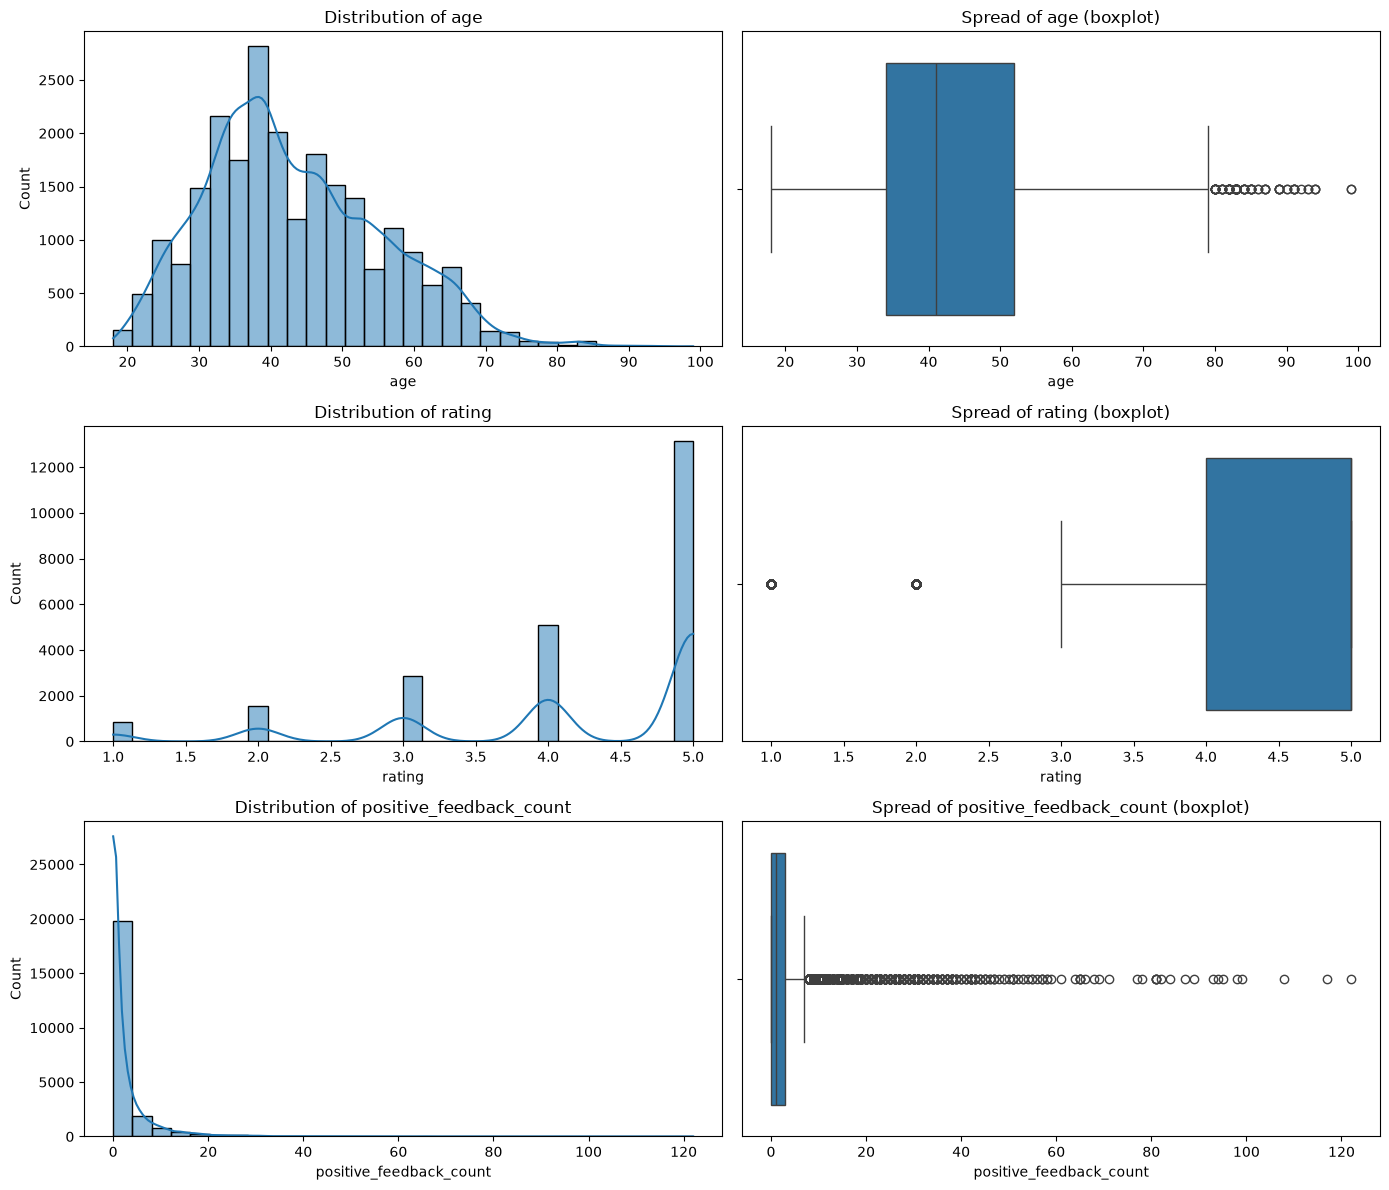

,count,mean,std,min,25%,50%,75%,max,IQR,skewness,kurtosis
age,23486.0,43.20,12.28,18.0,34.0,41.0,52.0,99.0,18.0,0.53,-0.11
rating,23486.0,4.20,1.11,1.0,4.0,5.0,5.0,5.0,1.0,-1.31,0.80
positive_feedback_count,23486.0,2.54,5.70,0.0,0.0,1.0,3.0,122.0,3.0,6.47,71.69


In [11]:
# Continuous attributes to profile univariately
continuous_cols = ['age', 'rating', 'positive_feedback_count']

# For each: histogram+KDE (distribution) on the left, boxplot (spread) on the right
fig, axes = plt.subplots(len(continuous_cols), 2, figsize=(14, 4*len(continuous_cols)))
for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution of {col}')
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Spread of {col} (boxplot)')
plt.tight_layout(); plt.show()

# Numeric distribution & spread statistics (incl. IQR, skew, kurtosis)
stats = df[continuous_cols].describe().T
stats['IQR']      = stats['75%'] - stats['25%']          # inter-quartile range (spread)
stats['skewness'] = df[continuous_cols].skew()           # asymmetry of distribution
stats['kurtosis'] = df[continuous_cols].kurtosis()       # tailedness
display(stats.round(2))

**Observations — continuous attributes**

- **Rating is strongly left-skewed** : Majority of reviews are 4–5 stars
  (5 star alone = ~13000), while only ~3000 are 1–2 stars. Negative reviews are a minority but
  high-value signal.
- **Age is roughly symmetric and slightly right-skewed** : centred around a
  mean age 43, spanning 18–99, with most reviewers in their **30s–40s**.
- **`positive_feedback_count` is extremely right-skewed** : ~20000 of reviews get
  0 helpful votes, yet a few viral reviews reach **122** — the
  long tail visible in both the histogram and boxplot.
- The boxplots confirm this: `rating` and `age` have compact spreads, whereas
  `positive_feedback_count` shows a dense box near zero with a long trail of high-value outliers.

### 2.2 Distribution of data across categories (categorical attributes)

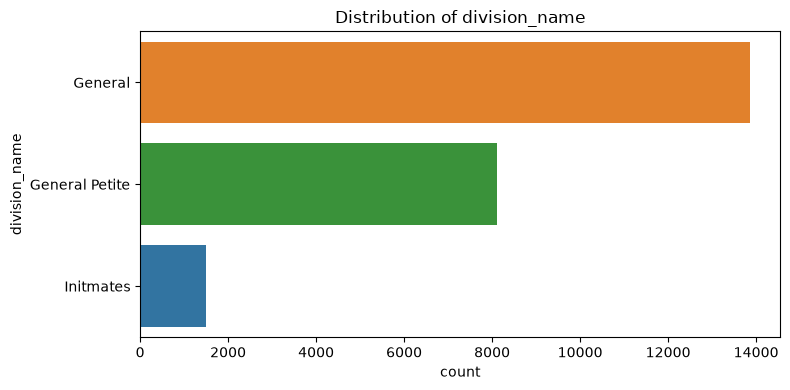

--- division_name (% share) ---
division_name
General           59.01
General Petite    34.59
Initmates          6.40 



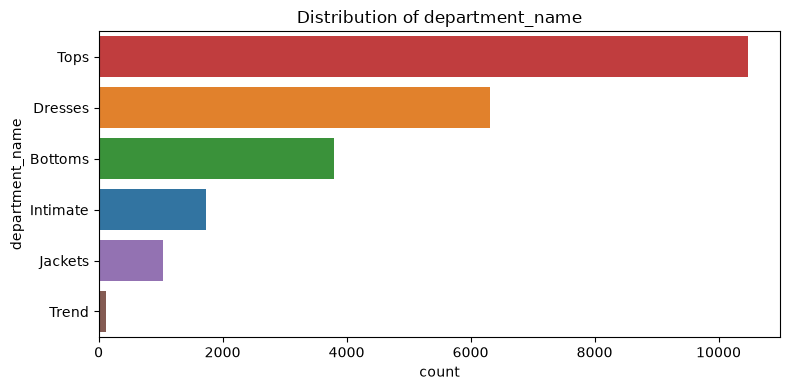

--- department_name (% share) ---
department_name
Tops        44.60
Dresses     26.92
Bottoms     16.19
Intimate     7.39
Jackets      4.40
Trend        0.51 



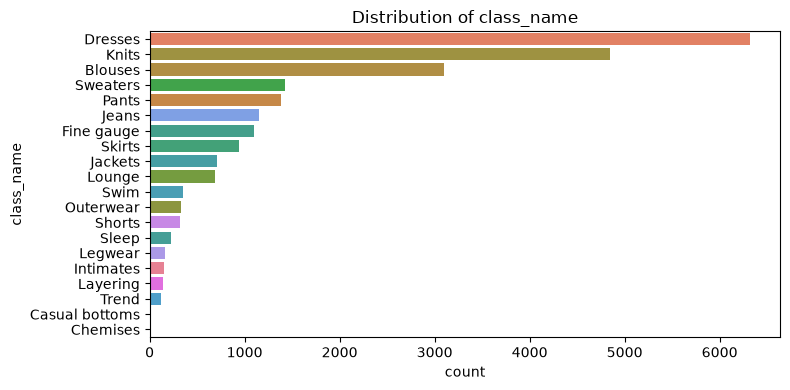

--- class_name (% share) ---
class_name
Dresses           26.92
Knits             20.63
Blouses           13.19
Sweaters           6.08
Pants              5.91
Jeans              4.89
Fine gauge         4.69
Skirts             4.03
Jackets            3.00
Lounge             2.94
Swim               1.49
Outerwear          1.40
Shorts             1.35
Sleep              0.97
Legwear            0.70
Intimates          0.66
Layering           0.62
Trend              0.51
Casual bottoms     0.01
Chemises           0.00 



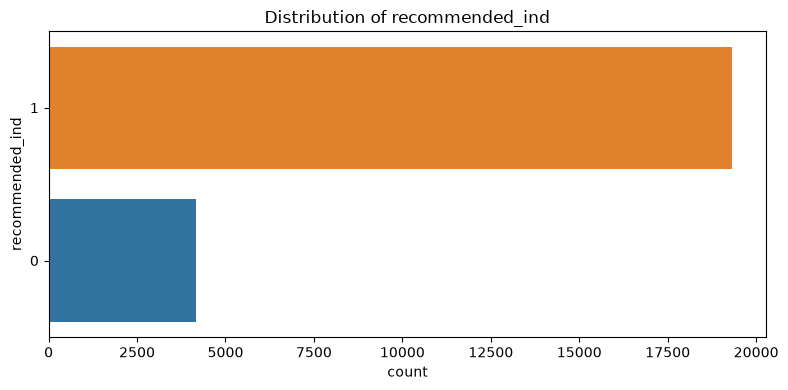

--- recommended_ind (% share) ---
recommended_ind
1    82.24
0    17.76 



In [12]:
# Categorical attributes (recommended_ind is a binary category)
cat_cols = ['division_name', 'department_name', 'class_name', 'recommended_ind']

# Plot each categorical attribute in its own separate graph
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index,
                  hue=col, legend=False)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

    # Print the percentage share of each category
    print(f'--- {col} (% share) ---')
    print((df[col].value_counts(normalize=True) * 100).round(2).to_string(), '\n')

**Observations — categorical attributes**

- **Division** is dominated by **General (~59%)** and **General Petite (~34.5%)**; *Intimates* is a
  small niche (~6.4%).
- **Department** is led by **Tops (~44.6%)** and **Dresses (~26.9%)** — together ~72% of all reviews;
  *Trend* is tiny (<0.5%), so its statistics will be noisy.
- **Class** is highly granular (**20 classes**); the top three — **Dresses (26.9%), Knits (20.6%),
  Blouses (13.2%)** — account for most of the volume, with a long tail of small classes.
- **Recommendation** is imbalanced: **82.2% recommend** vs **17.8% not** — consistent with the
  positive rating skew.

### 2.3 Bivariate analysis for important variables

#### 2.3.1 rating vs recommendation flag

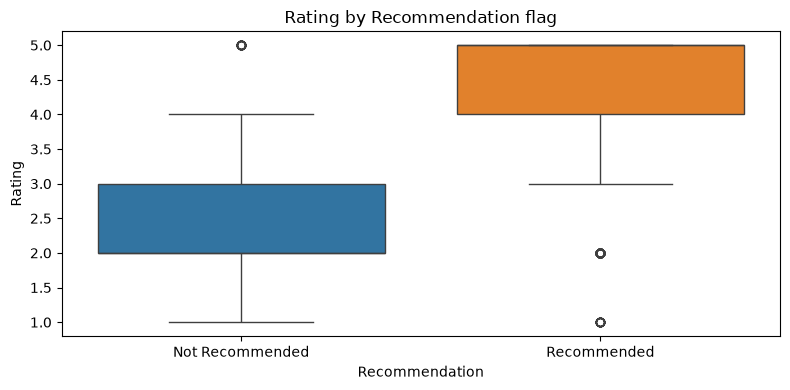

In [13]:
# (a) rating vs recommendation flag -> do higher ratings drive recommendations?
plt.figure(figsize=(8, 4))
sns.boxplot(x='recommended_ind', y='rating', data=df, hue='recommended_ind', legend=False)
plt.title('Rating by Recommendation flag')          
plt.xlabel('Recommendation')                         
plt.ylabel('Rating')                                 
plt.xticks([0, 1], ['Not Recommended', 'Recommended'])  
plt.tight_layout()
plt.show()


**Observations**

- **Clear separation:** recommended items average **4.6 star** vs. just **2.3 star**
  for non-recommended — the two groups barely overlap.
- **Strong positive correlation** between rating and recommendation.
- **Takeaway:** rating and recommendation carry almost the same signal, so a **low predicted
  rating is a strong indicator for "would not recommend"**.

#### 2.3.2 rating vs department

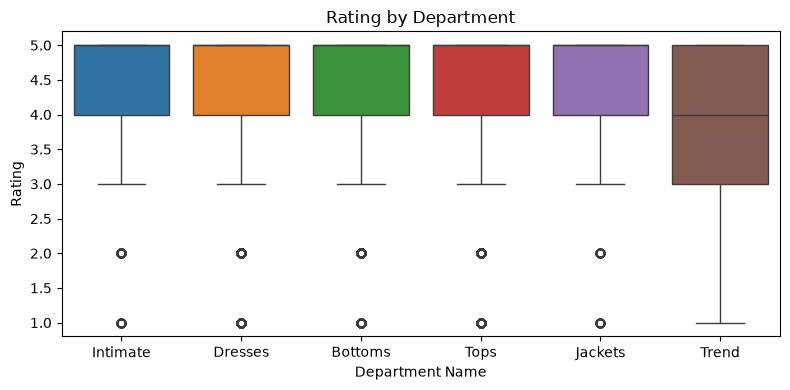

In [14]:

# (b) rating spread across departments -> which departments underperform?
plt.figure(figsize=(8, 4))
sns.boxplot(x='department_name', y='rating', data=df, hue='department_name', legend=False)

plt.title('Rating by Department')          
plt.xlabel('Department Name')                         
plt.ylabel('Rating')                                 
plt.tight_layout();
plt.show()


**Observations**

- **Ratings are consistently high across departments** — all sit between **~4.15 and 4.29**,
  medians near 4–5.
- **Trend is the clear laggard** at **3.82**.
- **Takeaway:** no department is broadly failing. but need to take care of Trend during peak season

#### 2.3.3 age vs rating

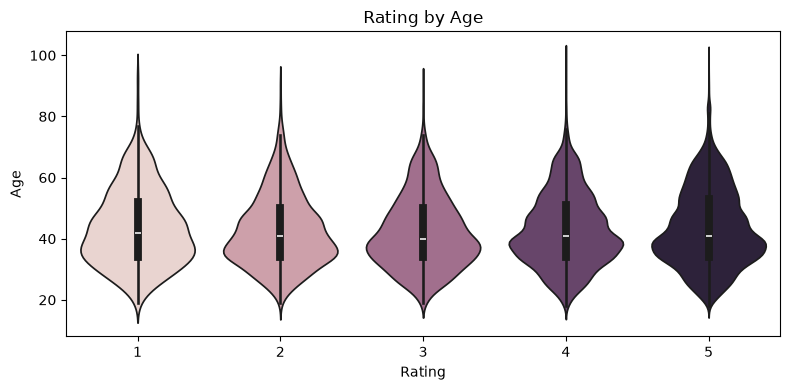

In [15]:
# (c) age distribution per rating -> is dissatisfaction age-related?
plt.figure(figsize=(8, 4))
sns.violinplot(x='rating', y='age', data=df, hue='rating', legend=False)

plt.title('Rating by Age')          
plt.xlabel('Rating')                         
plt.ylabel('Age') 
plt.tight_layout();
plt.show()


**Observations**

- **Age is essentially flat across ratings** — mean age stays ~**42–44** for every star level.
- **Near-zero correlation** between age and rating.
- Violin shapes are similar across all ratings (broad 30s–40s spread).
- **Takeaway:** dissatisfaction is **not age-driven**, so responses can stay
  demographic-agnostic — the signal lives in the review content, not the reviewer's age.

#### 2.3.4 recommendation vs department

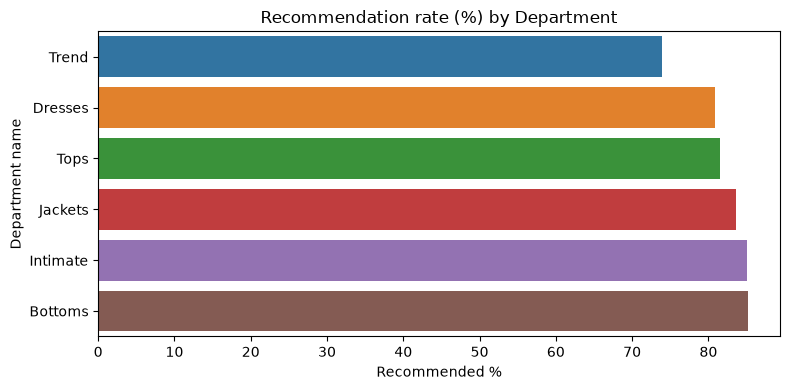

Mean rating by recommendation flag:
recommended_ind
0    2.3
1    4.6
Name: rating, dtype: float64


In [16]:
# (d) recommendation rate by department -> category-level satisfaction
plt.figure(figsize=(8, 4))
rec_rate = df.groupby('department_name')['recommended_ind'].mean().sort_values()*100
sns.barplot(x=rec_rate.values, y=rec_rate.index, hue=rec_rate.index, legend=False)

plt.title('Recommendation rate (%) by Department')          
plt.xlabel('Recommended %')                         
plt.ylabel('Department name') 

plt.tight_layout();
plt.show()

# Supporting numbers
print('Mean rating by recommendation flag:')
print(df.groupby('recommended_ind')['rating'].mean().round(2))

**Observations**

- **Most departments recommend at ~81–85%**, overall ~82% recommend rate.
- **Trend is a notable outlier at only ~74%** — the lowest satisfaction, consistent with its
  lowest average rating (3.82).
- *Bottoms (~85%)* and *Intimate (~85%)* have the happiest customers.
- **Takeaway:** **Trend is the weak spot** and should be prioritised for product/quality review,
  even though its low volume means fixes affect fewer customers.

### 2.4 Relationships between variables and their correlations

#### 2.4.1 Correlation among numeric attribute using Heat map

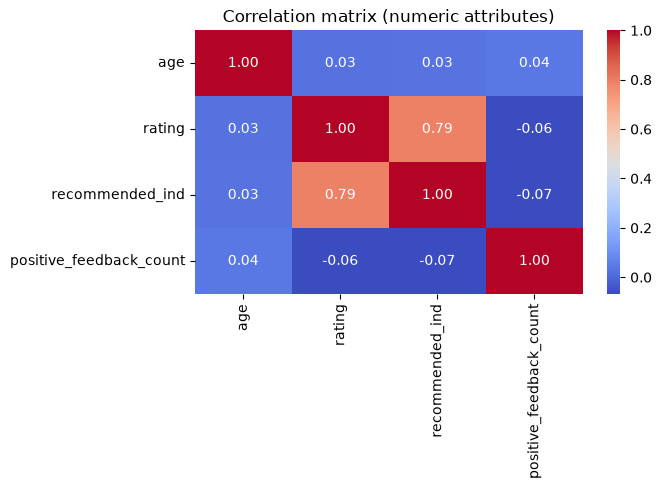

In [17]:
# Pearson correlation among numeric attributes
num_cols = ['age', 'rating', 'recommended_ind', 'positive_feedback_count']
corr = df[num_cols].corr()

# Heatmap of the correlation matrix
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix (numeric attributes)');
plt.tight_layout()
plt.show()



**Observations — correlation matrix**

- **One strong relationship dominates:** `rating` - `recommended_ind` at **r = 0.79** — high
  ratings almost always come with a recommendation.
- **Everything else is uncorrelated** (|r| < 0.07): `age`, `rating`,
  `recommended_ind` and `positive_feedback_count` move independently.
- **`positive_feedback_count` is weakly *negative*** with rating (−0.06) and recommendation
  (−0.07) — mildly critical reviews tend to attract slightly more "helpful" votes.
- **`age` is flat against all metrics** (r ≈ 0.03–0.04) — no demographic effect.
- **Takeaway:** the structured numeric columns carry **almost no relationship** on their own (aside from the rating/recommend overlap) — confirming the real
  signal lives in the **review text**.

#### 2.4.2 Relationship between continous variable using Pair plot

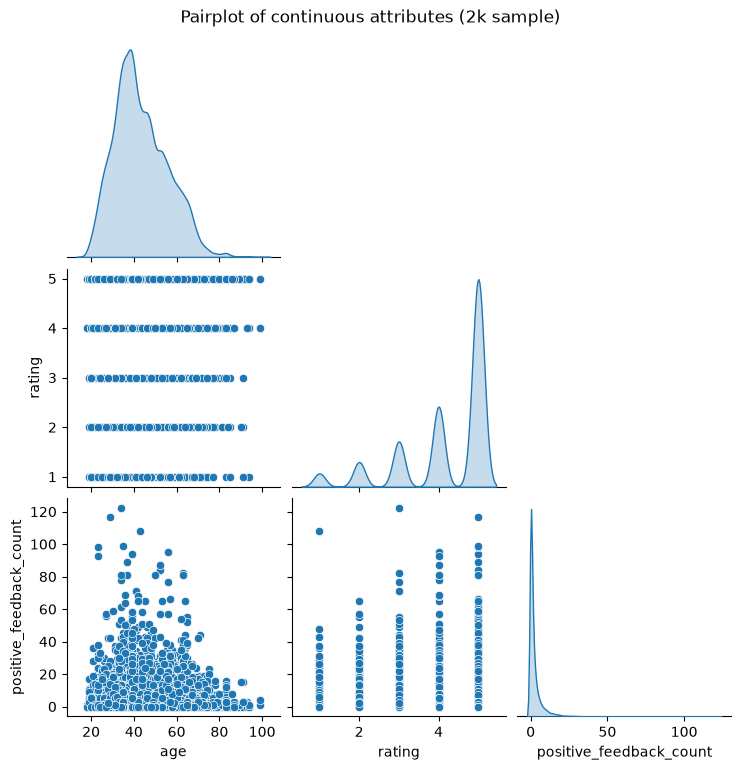

,age,rating,recommended_ind,positive_feedback_count
age,1.000,0.027,0.031,0.043
rating,0.027,1.000,0.792,-0.065
recommended_ind,0.031,0.792,1.000,-0.069
positive_feedback_count,0.043,-0.065,-0.069,1.000


In [18]:
# Pairplot on a sample to inspect joint relationships of continuous variables
sns.pairplot(df[['age', 'rating', 'positive_feedback_count']],
             diag_kind='kde', corner=True)
plt.suptitle('Pairplot of continuous attributes (2k sample)', y=1.02); plt.show()

corr.round(3)

**Observations — pairplot**

- **No linear trends** between `age`, `rating`, and `positive_feedback_count` — the scatter
  clouds are diffuse with no visible slope, matching the near-zero correlations.
- **KDE diagonals confirm univariate shapes:** `age` is roughly bell-shaped (centred ~41),
  `rating` clusters at the high end, and `positive_feedback_count` is sharply concentrated near
  zero with a long right tail.
- **Takeaway:** the continuous variables are **largely independent** — none can substitute for the text-based sentiment signal.

### 2.5 Data insights & summarization

In [19]:
# Compute headline metrics that summarise the dataset
print('KEY QUANTITATIVE INSIGHTS')
print('=' * 45)
print(f"Total reviews                 : {len(df):,}")
print(f"Mean rating                   : {df['rating'].mean():.2f} / 5")
print(f"% of 4-5 star reviews         : {(df['rating']>=4).mean()*100:.1f}%")
print(f"% recommended                 : {df['recommended_ind'].mean()*100:.1f}%")
print(f"Median reviewer age           : {df['age'].median():.0f} years")
print(f"Most-reviewed department      : {df['department_name'].value_counts().idxmax()}")
print(f"Lowest avg-rating department  : {df.groupby('department_name')['rating'].mean().idxmin()}")
print(f"Corr(rating, recommended_ind) : {df['rating'].corr(df['recommended_ind']):.2f}")

KEY QUANTITATIVE INSIGHTS
Total reviews                 : 23,486
Mean rating                   : 4.20 / 5
% of 4-5 star reviews         : 77.5%
% recommended                 : 82.2%
Median reviewer age           : 41 years
Most-reviewed department      : Tops
Lowest avg-rating department  : Trend
Corr(rating, recommended_ind) : 0.79


**Section 2 insights**

1. **Ratings skew positive** (strongly left-skewed) — 4–5 stars dominate, so negative reviews are a
   *minority but high-value*.
2. **Rating ↔ recommendation are tightly linked** — a low predicted rating is a reliable metrics for
   "would not recommend".
3. **`positive_feedback_count` is highly right-skewed** — most reviews get few helpful votes; a few
   go viral and deserve priority attention.
4. **Volume is concentrated** in *Tops* and *Dresses* — insights and response staffing should be
   weighted by department.
5. **Age barely correlates with rating** — dissatisfaction is not demographic-driven.


# Section 3 — Data Preprocessing

### 3.1 Remove unnecessary variables for model building (w.r.t. the target)
**Target variable = `rating`** (the objective is to *estimate the product rating*). We assess each
feature's usefulness for modelling and drop only what adds no predictive value.

In [20]:
# Remove exact duplicate records first (they bias any analysis/model)
dups = df.duplicated().sum()
print(f'Exact duplicate rows found: {dups}')
df = df.drop_duplicates().reset_index(drop=True)


Exact duplicate rows found: 21


In [21]:
# clothing_id is a pure IDENTIFIER (23k+ unique labels) -> no predictive signal w.r.t. rating.
# All other columns are kept: text = model input, division/department/class = context,
# age/positive_feedback_count = supporting features, recommended_ind = related label.
df = df.drop(columns=['clothing_id'])
print('Dropped: clothing_id (identifier, not predictive).')
print('Remaining columns:', list(df.columns))

Dropped: clothing_id (identifier, not predictive).
Remaining columns: ['age', 'title', 'review_text', 'rating', 'recommended_ind', 'positive_feedback_count', 'division_name', 'department_name', 'class_name']


### 3.2 Identify & treat missing values

#### 3.2.1 Count Missing values

In [22]:
# Identify: count and % of missing values per column
missing = pd.DataFrame({'missing': df.isnull().sum()})
missing

,missing
age,0
title,3789
review_text,825
rating,0
recommended_ind,0
positive_feedback_count,0
division_name,14
department_name,14
class_name,14


#### 3.2.2 Drop rows with missing reviews

In [23]:
# Treat (conservative strategy):
before = len(df)
# review_text is the CORE signal -> rows without it are unusable, so drop them
df = df.dropna(subset=['review_text']).reset_index(drop=True)
print(f'Dropped {before-len(df)} rows with empty review_text.')

Dropped 825 rows with empty review_text.


#### 3.2.3 Fill missing unrelated values

In [24]:
# title is optional -> fill missing with empty string
df['title'] = df['title'].fillna('')
# product-context categories: only a handful missing & co-occur -> label 'Unknown'
for col in ['division_name', 'department_name', 'class_name']:
    df[col] = df[col].fillna('Unknown')

print('Remaining missing values:', int(df.isnull().sum().sum()))

Remaining missing values: 0


### 3.3 Identify & treat outliers

In [25]:
# Use the IQR rule to flag outliers on the truly continuous columns.
def iqr_bounds(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr           # lower, upper fences

for col in ['age', 'positive_feedback_count']:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'{col}: IQR fences=({lo:.1f}, {hi:.1f}) -> {n_out} outliers ({n_out/len(df)*100:.2f}%)')

# Treatment: CAP (winsorize) age at its IQR fences so extreme ages don't distort stats.
lo, hi = iqr_bounds(df['age'])
df['age'] = df['age'].clip(lower=lo, upper=hi)

age: IQR fences=(7.0, 79.0) -> 108 outliers (0.48%)
positive_feedback_count: IQR fences=(-4.5, 7.5) -> 2147 outliers (9.48%)


**Observations — outlier identification & treatment**

- **`age`:** IQR fences ≈ **(7, 79)** → only **108 outliers (0.48%)** — a handful of
  unrealistically old reviewers.
- **`positive_feedback_count`:** IQR fences ≈ **(−4.5, 7.5)** → **2,147 flagged (9.48%)**, driven
  by its heavy right skew (median 1, max 122).
- **`rating` is excluded by design:** it is an **ordinal** score bounded to 1–5, so outliers are
  not meaningful — identification only.
- **Treatment of `age` → winsorizing:** capped to its IQR fences with `.clip()`, neutralising
  extreme ages **without deleting any rows** (conservative).
- **Treatment of `positive_feedback_count` → keep, don't cut:** the flagged high values are
  **genuine influential/viral reviews**, not errors, so they are retained.
- **Rationale:** capping fixes distorting noise (`age`) while preserving real business signal
  (`positive_feedback_count`) — outliers are *treated*, not blindly dropped.

### 3.4 Transform variables & add new variables

#### 3.4.1 Add sentiment variable

In [26]:
# (a) NEW: sentiment label derived from the target rating (used heavily in later milestones)
def rating_to_sentiment(r):
    if r <= 2:   return 'Negative'
    elif r == 3: return 'Neutral'
    else:        return 'Positive'
df['sentiment'] = df['rating'].apply(rating_to_sentiment)
df.head()


,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name,sentiment
0,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Positive
1,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Positive
2,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Neutral
3,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,Positive
4,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Positive


- Maps the ordinal `rating` into a 3-class **target label**: 1–2 → **Negative**, 3 → **Neutral**,
  4–5 → **Positive** — the ground truth the GenAI prompts will be evaluated against.
- Resulting mix is imbalanced: **~77.5% Positive, ~12% Neutral, ~10% Negative**, so the minority
  Negative class is the high-value one to catch.

#### 3.4.2 Add review_length variable

In [27]:
# (b) NEW: review_length = word count of the review (a useful engagement/effort signal)
df['review_length'] = df['review_text'].str.split().str.len()
df.head()


,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name,sentiment,review_length
0,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Positive,8
1,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Positive,62
2,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Neutral,98
3,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,Positive,22
4,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Positive,36


- Adds `review_length` = number of words in `review_text`, a cheap **engagement/effort** feature.
- Useful downstream as a proxy for urgency — unhappy customers tend to write longer reviews
  (explored in Section 4.1).

#### 3.4.3 Fix skewness

In [28]:
# (c) TRANSFORM: log1p of the highly-skewed feedback count to normalise its distribution
df['log_positive_feedback'] = np.log1p(df['positive_feedback_count'])
df.head()


,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name,sentiment,review_length,log_positive_feedback
0,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,Positive,8,0.000000
1,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,Positive,62,1.609438
2,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Neutral,98,0.000000
3,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,Positive,22,0.000000
4,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Positive,36,1.945910


- Applies `np.log1p` (= ln(count+1)) to the heavily right-skewed `positive_feedback_count`,
  safely handling the ~48% zeros.
- Reduces skew from **≈6.5 to ≈1.1**, making the feature usable for fair comparison and plots
  without deleting the genuine viral-review outliers.

#### 3.4.4 Add age_group variable

In [29]:
# (d) NEW: age_group buckets for readable demographic breakdowns
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 120],
                         labels=['<=25', '26-35', '36-45', '46-55', '55+'])

print('Added columns: sentiment, review_length, log_positive_feedback, age_group')
display(df[['rating', 'sentiment', 'review_length',
            'positive_feedback_count', 'log_positive_feedback', 'age', 'age_group']].head())

Added columns: sentiment, review_length, log_positive_feedback, age_group


,rating,sentiment,review_length,positive_feedback_count,log_positive_feedback,age,age_group
0,4,Positive,8,0,0.000000,33,26-35
1,5,Positive,62,4,1.609438,34,26-35
2,3,Neutral,98,0,0.000000,60,55+
3,5,Positive,22,0,0.000000,50,46-55
4,5,Positive,36,6,1.945910,47,46-55


- Bins continuous `age` into readable demographic bands (**≤25, 26–35, 36–45, 46–55, 55+**).
- Enables clear demographic breakdowns in reporting, though age showed little link to rating
  (r ≈ 0.03), so it's mainly descriptive.

### 3.5 Justification & summary of preprocessing

- **Duplicates —** dropped **21** exact duplicate rows, since repeated records bias distributions
  and any downstream model.
- **Feature relevance —** dropped **`clothing_id`**, a unique identifier that carries no predictive
  signal for the target `rating`.
- **Missing values —** dropped rows with empty **`review_text`** (the core signal, which cannot be
  imputed), and filled `title` → `''` and product categories → `'Unknown'`; these fields are safely
  recoverable, so the rows are preserved.
- **Outliers —** **winsorized `age`** to its IQR fences (extreme ages distort statistics) and **kept**
  `positive_feedback_count`, whose high values are *genuine viral reviews*, not errors.
- **Transformation —** added **`log_positive_feedback`** (`log1p`) to normalise the heavy right-skew
  for fair comparison.
- **New variables —** added  **`sentiment`**, **`review_length`**, and **`age_group`** to support
  sentiment analysis, engagement study, and demographic reporting.


# Section 4 — EDA Conclusion & Deep Dive

### 4.1 Relationships between variables — focus on the important ones

##### 4.1.1 Sentiment vs Department

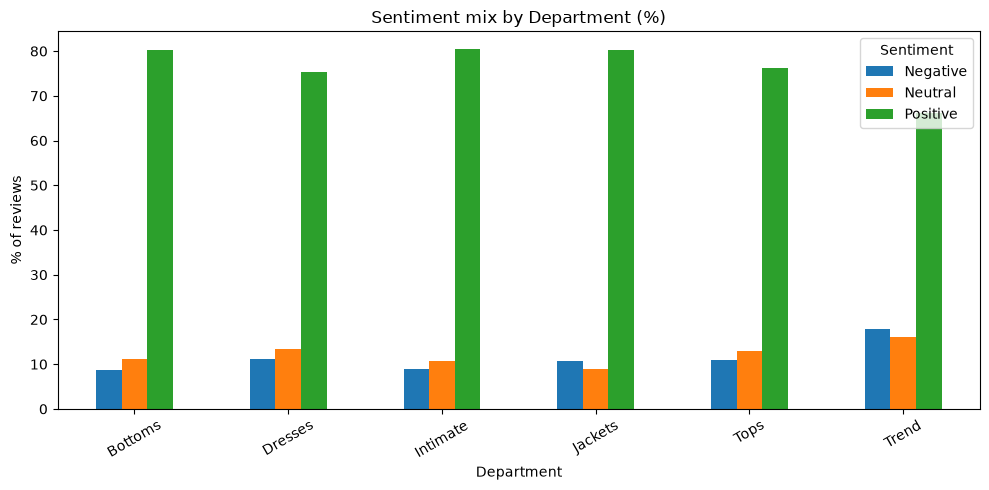

In [30]:
# sentiment mix within each department -> grouped bars
dep_sent = (df.groupby('department_name')['sentiment']
              .value_counts(normalize=True).unstack().fillna(0)*100)
dep_sent = dep_sent[['Negative', 'Neutral', 'Positive']]
dep_sent = dep_sent.drop('Unknown', errors='ignore') 

dep_sent.plot(kind='bar', figsize=(10, 5))
plt.title('Sentiment mix by Department (%)')
plt.xlabel('Department'); plt.ylabel('% of reviews')
plt.xticks(rotation=30); plt.legend(title='Sentiment')
plt.tight_layout(); plt.show()


- Sentiment is broadly consistent — most departments run **~75–80% Positive**, but **Trend is the
  clear weak spot** with the highest **Negative (17.8%)** and lowest **Positive (66%)** share.
- **Dresses and Tops** (the highest-volume departments) carry slightly more negativity (~11% each).

##### 4.1.2 Review Length vs Sentiment

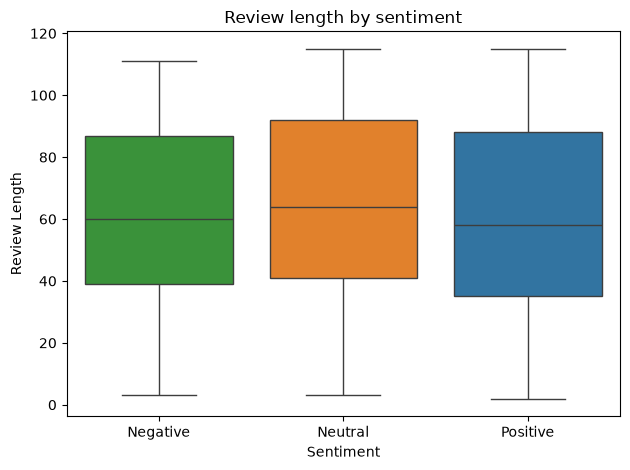

In [31]:
# review_length vs sentiment -> are unhappy customers more verbose?
sns.boxplot(x='sentiment', y='review_length', data=df,
            order=['Negative', 'Neutral', 'Positive'], hue='sentiment',
            legend=False)

plt.title('Review length by sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Length')
plt.tight_layout()
plt.show()




- Review length barely varies by sentiment: median words are **Negative 60, Neutral 64, Positive 58**
  — so, contrary to the common assumption, unhappy customers are **not** meaningfully more verbose here.
- **Neutral reviews are marginally the longest**, likely reflecting balanced "pros and cons" feedback;
  length is therefore a **weak** urgency signal on its own.

##### 4.1.3 Mean Rating vs Age Group

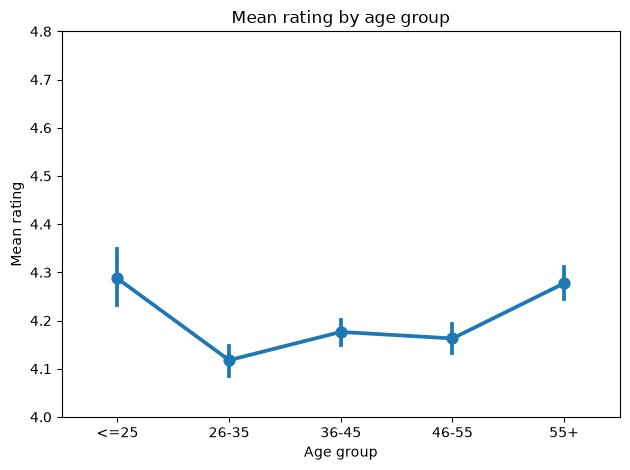

In [32]:
# mean rating by age_group -> satisfaction across demographics
order = df['age_group'].unique().sort_values()
sns.pointplot(x='age_group', y='rating', data=df, order=order)
plt.ylim(4, 4.8)
plt.title('Mean rating by age group')
plt.xlabel('Age group')
plt.ylabel('Mean rating')
plt.tight_layout()
plt.show()


- Average rating is **flat across age bands (~4.1–4.3)**, confirming satisfaction is not age-driven.
- The extremes are marginally happiest — **≤25 (4.29)** and **55+ (4.28)** — but the gap is too small
  to be practically meaningful.

##### 4.1.4 Correlation matrix

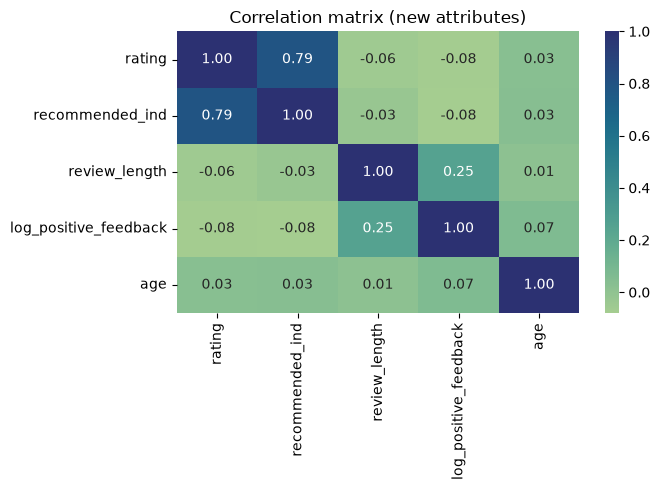

In [33]:
# Correlation incl. engineered numeric features
corr = df[['rating', 'recommended_ind', 'review_length',
            'log_positive_feedback', 'age']].corr()

# Heatmap of the correlation matrix
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='crest', fmt='.2f')
plt.title('Correlation matrix (new attributes)');
plt.tight_layout()
plt.show()

- The only strong link remains **`rating` ↔ `recommended_ind` (0.79)**; all engineered features stay
  weakly correlated with rating (|r| ≤ 0.08).
- A modest new signal emerges: **`review_length` ↔ `log_positive_feedback` (0.25)** — longer reviews
  tend to earn more "helpful" votes.

### 4.2 Detailed EDA visualizations with insights

#### 4.2.1 Sentiment distribution

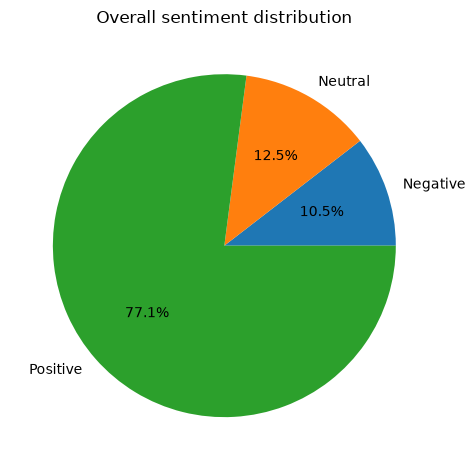

In [34]:
# (a) overall sentiment split -> scale of the negative-feedback workload
sent_counts = df['sentiment'].value_counts()[['Negative', 'Neutral', 'Positive']]
plt.pie(sent_counts, labels=sent_counts.index, autopct='%1.1f%%')
plt.title('Overall sentiment distribution')
plt.tight_layout()
plt.show()

- The dataset is **heavily positive**: **77.1% Positive (17,447)**, **12.5% Neutral (2,823)**,
  and only **10.5% Negative (2,370)** reviews.
- The small Negative slice defines the **operational workload** — ~2,370 reviews needing an
  apology/response — and is the *minority-but-critical* class.

#### 4.2.2 Negative reviews by department

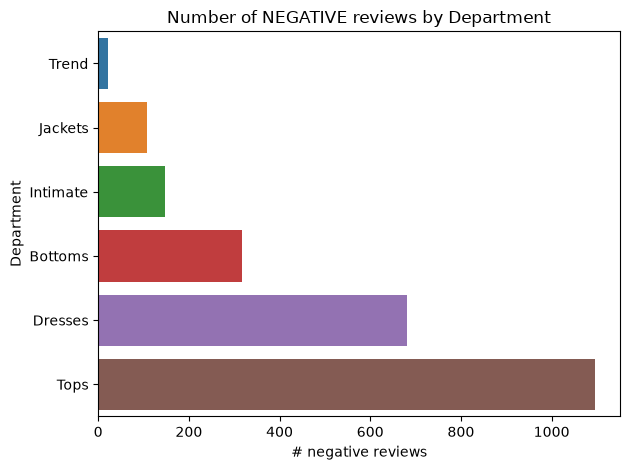

Negative reviews: 2,370 (10.5% of total)


In [35]:
# (b) count of NEGATIVE reviews by department -> where to prioritise response teams
neg_by_dep = (df[df['sentiment'] == 'Negative']['department_name']
              .value_counts().sort_values())
sns.barplot(x=neg_by_dep.values, y=neg_by_dep.index, hue=neg_by_dep.index, legend=False)
plt.title('Number of NEGATIVE reviews by Department')
plt.xlabel('# negative reviews')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

print(f"Negative reviews: {(df['sentiment']=='Negative').sum():,} "
      f"({(df['sentiment']=='Negative').mean()*100:.1f}% of total)")

- Negative reviews concentrate in the **high-volume departments**: **Tops (1,096)** and
  **Dresses (681)** alone make up **~75%** of all 2,370 negatives.
- This is a **volume effect, not a quality effect** — Tops/Dresses have normal negativity *rates*
  (~11%) but dominate absolute complaint counts, so **response staffing should be prioritised there**;
  *Trend (21)* has few complaints in count despite its high negativity rate.

### 4.3 Justification of insights & inference

- **Most reviews are happy ones.** About 77% are Positive and only ~10% Negative. The real job is
  finding the few urgent complaints hidden among many good reviews.
- **Complaints pile up in the busiest departments.** Tops and Dresses have the most negative reviews
  simply because they get the most reviews overall, not because they are worse. So response teams
  should be sized by the *number* of complaints, not just the complaint rate.
- **Review length says little about sentiment.** Negative, Neutral, and Positive reviews are all
  about the same length (~58–64 words), so how long a review is does not reliably tell us if the
  customer is upset — the meaning has to come from the actual words.
- **The number columns can't predict satisfaction on their own.** Rating lines up closely with
  "recommended", but has almost no link to age or feedback count. This confirms the useful signal
  lives in the **review text**.


## Save the cleaned & enriched dataset

In [36]:
# Persist the processed dataframe for the next milestones
df.to_csv('cleaned_reviews.csv', index=False)
print('Saved cleaned_reviews.csv | shape:', df.shape)
print('Columns:', list(df.columns))

Saved cleaned_reviews.csv | shape: (22640, 13)
Columns: ['age', 'title', 'review_text', 'rating', 'recommended_ind', 'positive_feedback_count', 'division_name', 'department_name', 'class_name', 'sentiment', 'review_length', 'log_positive_feedback', 'age_group']
